In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('diffusionsim')))
from tqdm import tqdm
from pathlib import Path
import json
import numpy as np
import diffusionsim.training_utils as tru
import torch
from typing import Optional
from dataclasses import dataclass, asdict, field
from typing_extensions import Annotated
from pprint import pprint
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import scipy.stats as stats

In [2]:
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/srv/conda/envs/notebook'
torch.set_grad_enabled(False); print("grad enabled: ", torch.is_grad_enabled())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

grad enabled:  False


'cuda'

## Comparing MSE models to DistLoss models

In [5]:
targeted_vars = [68, 60, 73, 82]
num_gaussians = [3, 2, 3, 2]

In [19]:
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "DistLossTesting"
run_id = "trial1"
base_dir = os.path.join(exp_dir, exp_id)
log_dicts = {}
mconfigs = []
distloss_models = {}
lettering = 'abcdefghijklmnopqrstuvwxyz'
for i in range(4):
    fpath = os.path.join(base_dir, f"trial1{lettering[i]}.json")
    print(fpath)
    with open(fpath, 'r') as f:
        log_dict = json.load(f)
    model_path = os.path.join(base_dir, "checkpoints", )
    mconfig = tru.ModelConfig(**log_dict['model_config'])
    mconfigs.append(mconfig)
    distloss_models[targeted_vars[i]] = tru.load_model_from_ckpt(f"checkpoints/{run_id}{lettering[i]}-ckpt.pt", mconfig, exp_id, exp_dir, baseline=True)
    log_dicts[targeted_vars[i]] = log_dict


/mnt/home/ssa2206/Climsim/experiments/DistLossTesting/trial1a.json


TypeError: load_model_from_ckpt() got an unexpected keyword argument 'baseline'

In [ ]:
mse_base_dir = os.path.join(exp_dir, "JointTraining")
with open(mse_base_dir + "/trial0.json", 'r') as f:
    mse_log_dict = json.load(f)
mse_model = tru.load_model_from_ckpt("checkpoints/trial0_just_mse.pt", mse_log_dict['model_config'], "JointTraining", exp_dir, baseline=True).to(device)


/mnt/home/ssa2206/Climsim/diffusion-climsim/diffusionsim/diffusionsim/training_utils.py:206: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(c

In [17]:
mse_model

Sequential(
  (0): Linear(in_features=124, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): ReLU()
  (6): Linear(in_features=256, out_features=128, bias=True)
)

In [16]:
dconfig = tru.my_dconfig(data_vars='v1', in_notebook=True, climsim_training=True, batch_size=64)
dconfig.train_test_split = [0.01, 0.002]
dataloaders, indices = tru.load_dataloaders(dconfig, log=True, shuffle_indices=False)

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [7]:
dl, edl = dataloaders
batch = dl.dataset[8]

{"event": "get-batch start", "time": 1744118216.1315546, "pid": 2574277, "batch_idx": 8}
{"event": "get-batch end", "time": 1744118220.6452198, "pid": 2574277, "batch_idx": 8, "duration": 4.5136566162109375}


In [9]:
import dask
from dask.diagnostics import ProgressBar
with ProgressBar():
    edl.dataset.X.load()
    edl.dataset.Y.load()

In [104]:
batch = edl.dataset[5]
x, y = batch[0].to(device), batch[1].to(device)

{"event": "get-batch start", "time": 1744122156.2039487, "pid": 2574277, "batch_idx": 5}
{"event": "get-batch end", "time": 1744122156.2349157, "pid": 2574277, "batch_idx": 5, "duration": 0.03096151351928711}


In [106]:
predictions = {}
for var in targeted_vars:
    predictions[var] = distloss_models[var](x)


predictions['mse'] = mse_model(x)

In [107]:
predictions


{68: tensor([[ 0.2682,  0.2132,  0.1848,  ...,  0.1844,  0.0866,  0.0147],
         [ 0.1916,  0.1269,  0.1694,  ...,  0.0873,  0.0887,  0.0439],
         [ 0.4504,  0.4876,  0.3385,  ...,  0.3077,  0.1250,  0.0480],
         ...,
         [ 0.1038,  0.1911,  0.3227,  ..., -0.1903, -0.0812,  0.0690],
         [ 0.1038,  0.1859,  0.4136,  ..., -0.2416, -0.0262,  0.1082],
         [ 0.0784,  0.1969,  0.1825,  ..., -0.0945, -0.0205,  0.0768]],
        device='cuda:0'),
 60: tensor([[nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan],
         ...,
         [nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan]], device='cuda:0'),
 73: tensor([[ 0.1443,  0.2133,  0.1785,  ...,  0.1340,  0.1028, -0.0565],
         [ 0.0928,  0.1262,  0.0813,  ...,  0.0322,  0.0919,  0.0289],
         [ 0.2824,  0.4183,  0.4942,  ...,  0.1709,  0.1208, -0.

In [110]:
targeted_vars = [68, 60, 73, 82]
num_gaussians = [3, 2, 3, 2]

VAR_IND = 68
num_gaussians = 3

In [56]:
predictions[68].shape

torch.Size([24576, 128])

In [46]:
y_sel = y[:, VAR_IND].detach().cpu().numpy()
gmm = GaussianMixture(n_components=num_gaussians)
gmm.fit(y_sel[:, None])

x = 

GaussianMixture(n_components=3)

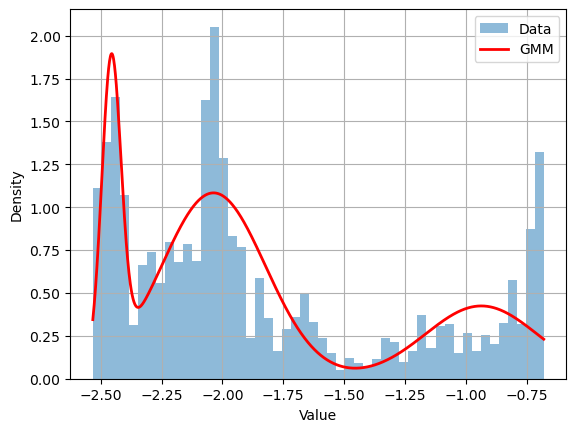

In [48]:
densities = plot_gmm_distribution(gmm, y_sel)

In [57]:
mlo = edl.dataset.mlo

In [112]:
from ipywidgets import interact, widgets
from matplotlib import pyplot as plt

def discrepancy_viewer(predictions, cmap='viridis'):
    # Define interactive plot function
    viewable_keys = [68, 73, 82, 'mse', 'true']
    var_inds = [68, 73, 82]
    num_gaussians = [3, 3, 2]

    def plot_image(var_index, index):
        VAR_IND = var_inds[var_index]
        y_sel = y[:, VAR_IND].detach().cpu().numpy()
        gmm = GaussianMixture(n_components=num_gaussians[var_index])
        gmm.fit(y_sel[:, None])
        if(viewable_keys[index] == 'true'):
            pred = y_sel
        else:
            pred = predictions[viewable_keys[index]][:, VAR_IND].detach().cpu().numpy()

        x = torch.linspace(y_sel.min(), y_sel.max(), 1000)
        densities = torch.exp(torch.tensor(gmm.score_samples(x.reshape(-1,1))))
        plt.plot(x, densities, label='gmm density learned from y')
        plt.hist(pred, density=True, label=f'{viewable_keys[index]} predictions', bins=50, alpha=0.75)
        #plt.hist(y_sel, density=True, label='histogram of y', bins=50, alpha=0.5)
        plt.title(f"Predictions of {mlo[VAR_IND].item()} ({VAR_IND}) from model {viewable_keys[index]}")
        plt.legend()
        plt.show()

    # Create interactive widgets
    variable_slider = widgets.IntSlider(value=0, min=0, max=len(var_inds)-1, step=1, description='Variable:')
    model_slider = widgets.IntSlider(value=0, min=0, max=len(viewable_keys)-1, step=1, description='Model:')
    interact(plot_image, var_index=variable_slider, index=model_slider)
    

In [113]:
discrepancy_viewer(predictions)

interactive(children=(IntSlider(value=0, description='Variable:', max=2), IntSlider(value=0, description='Mode…

In [124]:
log_dicts[68]['mse_loss']

[4.527252197265625,
 4.550696849822998,
 4.119123458862305,
 3.8886404037475586,
 3.911012649536133,
 3.357983350753784,
 3.0401313304901123,
 2.549130916595459,
 1.8338078260421753,
 1.4429019689559937]

In [83]:
log_dicts[68]['losses'].keys(), log_dicts[68].keys()

(dict_keys(['train', 'eval', 'mse', 'total', 'distribution']),
 dict_keys(['training_config', 'model_config', 'data_config', 'best_loss', 'losses', 'train_loss', 'eval_loss', 'mse_loss', 'total_loss', 'distribution_loss']))

In [84]:
log_dicts[68]['losses']['distribution']

[608.4487290577996,
 91.63995440111174,
 25.008587602670577,
 3.952058943332647,
 1.5230343460759823,
 1.3789262776476883,
 1.089513006941102,
 0.7624602114499852,
 2.0283779477402644,
 2.5872405428406804]

In [99]:
log_dicts.keys()

dict_keys([68, 60, 73, 82])

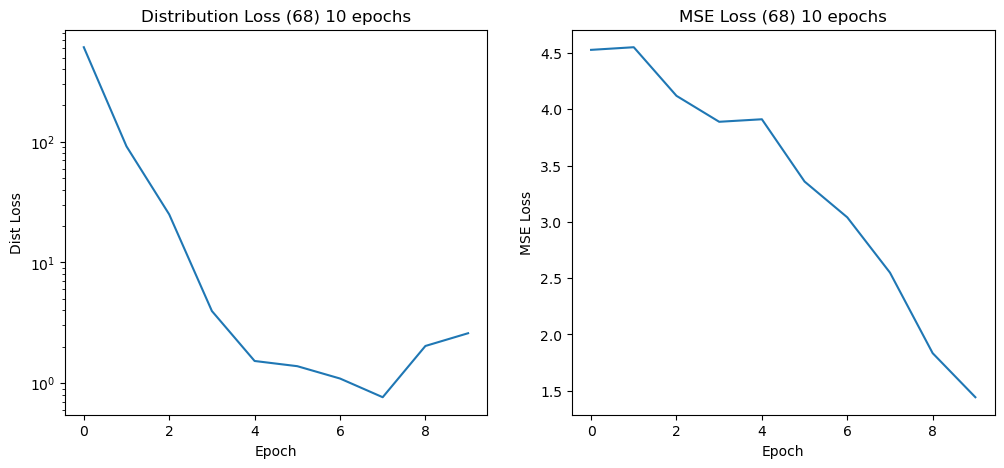

In [115]:
key = 68
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  # Create 2 subplots side by side
ax1.plot(log_dicts[key]['distribution_loss'], label='distribution')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Dist Loss')
ax1.set_yscale('log')
ax1.set_title(f'Distribution Loss ({key}) 10 epochs')
ax2.plot(log_dicts[key]['mse_loss'], label='mse')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE Loss')
ax2.set_title(f'MSE Loss ({key}) 10 epochs')

plt.show()


In [118]:
log_dicts.keys()

dict_keys([68, 60, 73, 82])

In [120]:
losses = []
key = 68
loss_fn = torch.nn.MSELoss()
for step, (x, y) in enumerate(edl):
    x = x.to(device)
    y = y.to(device)
    y_hat = distloss_models[key](x)
    mse_loss = loss_fn(y_hat, y)
    losses.append(mse_loss.item())
    

{"event": "get-batch start", "time": 1744122558.546282, "pid": 2574277, "batch_idx": 2}
{"event": "get-batch end", "time": 1744122558.5724804, "pid": 2574277, "batch_idx": 2, "duration": 0.02618694305419922}
{"event": "get-batch start", "time": 1744122558.7202022, "pid": 2574277, "batch_idx": 5}
{"event": "get-batch end", "time": 1744122558.73105, "pid": 2574277, "batch_idx": 5, "duration": 0.010845661163330078}
{"event": "get-batch start", "time": 1744122558.7360487, "pid": 2574277, "batch_idx": 0}
{"event": "get-batch end", "time": 1744122558.7495153, "pid": 2574277, "batch_idx": 0, "duration": 0.013464689254760742}
{"event": "get-batch start", "time": 1744122558.7539594, "pid": 2574277, "batch_idx": 4}
{"event": "get-batch end", "time": 1744122558.7666261, "pid": 2574277, "batch_idx": 4, "duration": 0.012664794921875}
{"event": "get-batch start", "time": 1744122558.7704258, "pid": 2574277, "batch_idx": 1}
{"event": "get-batch end", "time": 1744122558.7810912, "pid": 2574277, "batch_

In [122]:
np.mean(losses)

np.float64(1.8108816345532734)

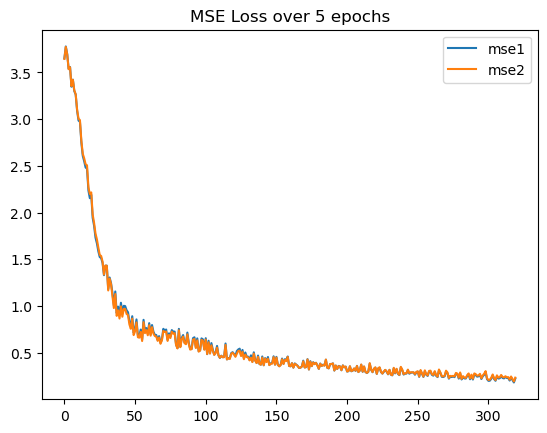

In [23]:
plt.plot(np.array(mse_log_dict['mse_only_losses']['mse']), label='mse1')
plt.plot(np.array(mse_log_dict['dist_losses']['mse']), label='mse2')
plt.title('MSE Loss over 5 epochs')
plt.legend()
plt.show()

In [24]:
lw1 = {'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0}
lw2 = {'mse': 1.0, 'distribution': 3e-4, 'diffusion': 0.0}

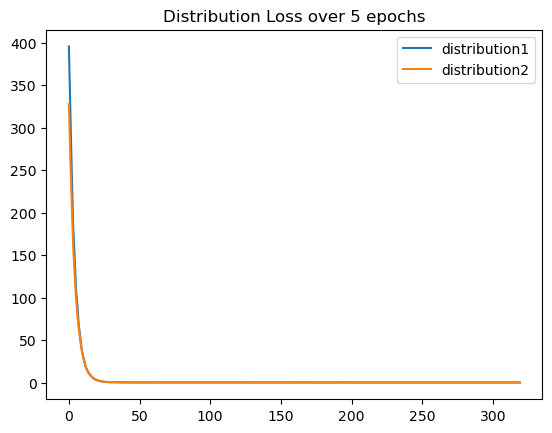

In [27]:
plt.plot(np.array(mse_log_dict['mse_only_losses']['distribution']), label='distribution1')
plt.plot(np.array(mse_log_dict['dist_losses']['distribution']), label='distribution2')
plt.title('Distribution Loss over 5 epochs')
plt.legend()
plt.show()

In [9]:
(train_ds, test_ds), (train_indices, test_indices) = data.load_dataset(dconfig)

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [14]:
x, y = train_ds[0]
x.shape, y.shape


(torch.Size([12288, 124]), torch.Size([12288, 128]))

In [46]:
model_mse = tru.build_baseline_model(mconfig, from_ckpt=True, ckpt_path=os.path.join(base_dir, f"trial0_just_mse.pt"))
model_dist = tru.build_baseline_model(mconfig, from_ckpt=True, ckpt_path=os.path.join(base_dir, f"trial0_dist_loss.pt"))

model_mse.eval().to(device)
model_dist.eval().to(device)

Sequential(
  (0): Linear(in_features=124, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): ReLU()
  (6): Linear(in_features=256, out_features=128, bias=True)
)

### Plotting Utils

In [51]:
def eval_density(GMM, x, training=True, return_components=False):
    x = x[:, None]
    mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] # (n_components,) (nc, d=1 flattened)
    pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] # (n_components,)
    var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] 
    log_probs = -0.5 * torch.log(2 * torch.pi * var) - (x - mu)**2 / (2 * var) 
    probs = torch.exp(log_probs)  # (N, K)
    weighted_probs = pi * probs
    q_x = weighted_probs.sum(dim=1, keepdim=True)  # (N, 1)
    if(return_components):
        return(q_x, weighted_probs)
    return(q_x)

In [34]:
def hist(data, title, **kwargs):
    if(isinstance(data, torch.Tensor)):
        data = data.detach().cpu().numpy()
    plt.hist(data, **kwargs)
    if('label' in kwargs):
        plt.legend()
    plt.title(title)

def plot_gmm_distribution(gmm, data, n_points=1000, components=False):
    if(isinstance(data, torch.Tensor)):
        data = data.detach().cpu().numpy()
    # Create a range of x values to evaluate the GMM on
    x = torch.linspace(data.min(), data.max(), n_points)
    ret = eval_density(gmm, x, training=False, return_components=components)
    # Plot histogram of actual data
    plt.hist(data, bins=50, density=True, alpha=0.5, label='Data')
    
    # Plot GMM density
    plt.plot(x, ret[0], 'r-', lw=2, label='GMM')
    if(components):
        plt.plot(x, ret[1][:,0], 'b-', lw=2, label='Component 1')
        plt.plot(x, ret[1][:,1], 'g-', lw=2, label='Component 2')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.show()
    return(ret[0])

## Trying to use data utils
- replicate https://leap-stc.github.io/ClimSim/evaluation/main_figure_generation.html
- https://github.com/leap-stc/ClimSim/blob/main/preprocessing/create_npy_data_splits.ipynb

Inspired by [Climsim guide](https://leap-stc.github.io/ClimSim/evaluation/main_figure_generation.html)

In [26]:
dutils = cut.setup_data_utils(dconfig.climsim_type, dconfig.source, dconfig.data_vars, 
                            use_tendencies=dconfig.use_tendencies, data_dir=dconfig.data_dir)

In [29]:
    test_ds.X

<xarray.DataArray 'state_t' (sample: 161280, mli: 124)> Size: 160MB
dask.array<transpose, shape=(161280, 124), dtype=float64, chunksize=(23808, 8), chunktype=numpy.ndarray>
Coordinates:
    lat       (sample) float64 1MB -32.59 -35.99 -22.69 ... 45.34 45.34 40.39
    lon       (sample) float64 1MB -39.73 -28.47 -39.56 ... 123.3 146.7 135.0
  * mli       (mli) object 992B MultiIndex
  * variable  (mli) <U11 5kB 'state_t' 'state_t' ... 'pbuf_LHFLX' 'pbuf_SHFLX'
  * lev       (mli) object 992B 0 1 2 3 4 5 6 7 ... 56 57 58 59 nan nan nan nan
  * sample    (sample) object 1MB MultiIndex
  * time      (sample) object 1MB 0001-03-02 05:20:00 ... 0001-03-08 01:00:00
  * ncol      (sample) int64 1MB 0 1 2 3 4 5 6 7 ... 377 378 379 380 381 382 383

In [31]:

from dask.diagnostics import ProgressBar
with ProgressBar():
    test_ds.X = test_ds.X.compute()
    test_ds.Y = test_ds.Y.compute()

[########################################] | 100% Completed | 5.35 sms


In [39]:
test_ds.X.data.shape

(161280, 124)

In [80]:
x_test = test_ds.X.data
y_test = test_ds.Y.data

x_test_norm = (x_test - test_ds.xm.numpy()) / test_ds.xs.numpy()
y_test_norm = (y_test - test_ds.ym.numpy()) / test_ds.ys.numpy()

y_mse_test = model_mse(torch.tensor(x_test_norm, dtype=torch.float32).to(device)).detach().cpu().numpy()
y_dist_test = model_dist(torch.tensor(x_test_norm, dtype=torch.float32).to(device)).detach().cpu().numpy()

In [81]:
y_test_norm, y_mse_test

(array([[-0.60654589, -0.63565834, -1.20754148, ..., -0.63062456,
         -0.73257194, -0.60943697],
        [-1.04401246, -0.82240929, -1.29353927, ..., -0.63062456,
         -0.73257194, -0.60943697],
        [ 0.42072694,  0.19917645, -0.11957182, ..., -0.63062456,
         -0.73257194, -0.60943697],
        ...,
        [ 1.36678694,  0.46805456, -0.20182888, ..., -0.63062047,
          0.27487803,  0.54659575],
        [ 1.76110789,  1.51138283,  0.6774151 , ...,  1.09071919,
          2.03586621,  1.93033042],
        [ 1.38972985,  2.36698824,  1.57617047, ..., -0.56559484,
          0.60883392,  1.02901249]]),
 array([[-0.01379928, -0.05070778, -0.06511268, ...,  0.12229963,
          0.2551429 ,  0.32771102],
        [-0.34561852, -0.57605433, -0.58625686, ...,  0.17825034,
          0.15522417,  0.21152176],
        [ 0.46206346,  0.5142341 ,  0.54526335, ..., -0.04397313,
          0.1996611 ,  0.28764543],
        ...,
        [-0.01723652,  0.08961765,  0.16961226, ..., -

In [82]:
loss = torch.nn.MSELoss()

loss(torch.tensor(y_test_norm), torch.tensor(y_mse_test))

tensor(0.2303, dtype=torch.float64)

In [85]:
loss(torch.tensor(y_test_norm), torch.tensor(y_dist_test))

tensor(0.2401, dtype=torch.float64)

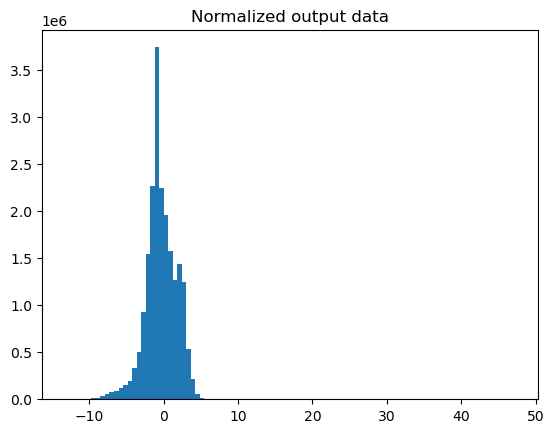

In [93]:
plt.hist(y_test_norm.flatten(), bins=100)
plt.title("Normalized output data")
#plt.hist(y_mse_test.flatten(), bins=10)
#plt.hist(y_dist_test.flatten(), bins=10)
plt.show()

In [94]:
mu_real, sigma_real = np.mean(y_test_norm), np.std(y_test_norm)
mu_mse, sigma_mse = np.mean(y_mse_test), np.std(y_mse_test)
mu_dist, sigma_dist = np.mean(y_dist_test), np.std(y_dist_test)



In [95]:
mu_real, mu_mse, mu_dist

(np.float64(-0.35196832216689283),
 np.float32(-0.36175743),
 np.float32(-0.36169025))

In [96]:
sigma_real, sigma_mse, sigma_dist

(np.float64(2.084488076556322), np.float32(2.016912), np.float32(2.0150366))

Text(0.5, 1.0, 'MSE model on normalized input')

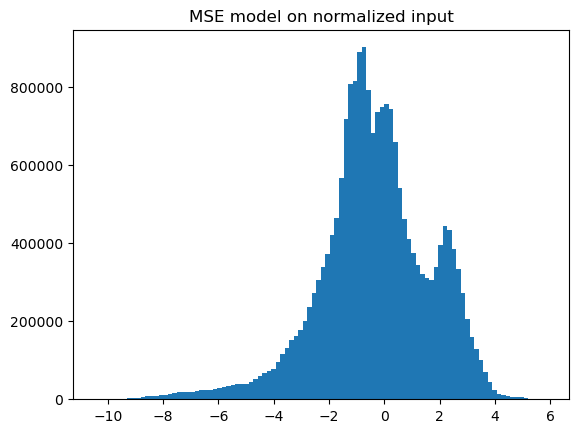

In [99]:
plt.hist(y_mse_test.flatten(), bins=100)
plt.title("MSE model on normalized input")

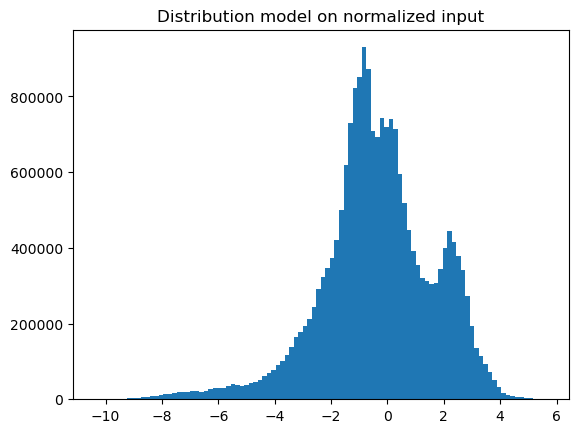

In [100]:
plt.hist(y_dist_test.flatten(), bins=100)
plt.title("Distribution model on normalized input")
plt.show()

In [65]:
dutils.input_scoring = x_test_norm
dutils.target_scoring = y_test_norm
# set pressure weights
dutils.set_pressure_grid(data_split = 'scoring')

# load model predictions
dutils.model_names = ['mse_model', 'dist_model']
predictions = {
    'mse_model' : y_mse_test, 
    'dist_model' : y_dist_test
}

dutils.preds_scoring = predictions

1. Undo output scaling

2. Weight vertical levels by dp/g
3. Weight horizontal area of each grid cell by a[x]/mean(a[x])
4. Convert units to a common energy unit

In [61]:
y_test

array([[2.11955523e+02, 2.22814364e+02, 2.29187058e+02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.09319429e+02, 2.21327028e+02, 2.28610102e+02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.18145683e+02, 2.29463219e+02, 2.36486204e+02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [2.23846468e+02, 2.31604638e+02, 2.35934344e+02, ...,
        4.35842573e-04, 4.60220406e+01, 3.35470072e+01],
       [2.26222575e+02, 2.39913993e+02, 2.41833158e+02, ...,
        1.83709516e+02, 1.26466997e+02, 7.37017160e+01],
       [2.23984718e+02, 2.46728271e+02, 2.47862872e+02, ...,
        6.94026290e+00, 6.12777178e+01, 4.75462976e+01]])

In [54]:
dutils.reweight_target(data_split = 'scoring')
dutils.reweight_preds(data_split = 'scoring')


In [56]:
dutils.target_vars

['state_t',
 'state_q0001',
 'cam_out_NETSW',
 'cam_out_FLWDS',
 'cam_out_PRECSC',
 'cam_out_PRECC',
 'cam_out_SOLS',
 'cam_out_SOLL',
 'cam_out_SOLSD',
 'cam_out_SOLLD']

In [59]:
dutils.preds_weighted_scoring

{'mse_model': {'ptend_t': array([[[ 3.12060897e+02, -4.58239002e+02, -1.60931285e+03, ...,
           -3.68976511e+09, -1.06955413e+10, -8.23473956e+09],
          [ 3.51314176e+02, -5.17108946e+02, -1.81598226e+03, ...,
           -4.22617983e+09, -1.21845763e+10, -9.39267819e+09],
          [ 3.43838252e+02, -5.02598156e+02, -1.76665485e+03, ...,
           -3.93284564e+09, -1.14965178e+10, -8.83419609e+09],
          ...,
          [ 3.20966104e+02, -5.02227032e+02, -1.72303777e+03, ...,
           -3.49281941e+09, -1.02881298e+10, -7.98506819e+09],
          [ 3.37911252e+02, -5.14463074e+02, -1.78252651e+03, ...,
           -3.91443995e+09, -1.13605104e+10, -8.81082609e+09],
          [ 3.01597252e+02, -4.64552554e+02, -1.60361090e+03, ...,
           -3.46086240e+09, -1.01110619e+10, -7.85837988e+09]],
  
         [[ 3.12039292e+02, -4.58175726e+02, -1.60909554e+03, ...,
           -3.68905789e+09, -1.06935925e+10, -8.23325932e+09],
          [ 3.51273425e+02, -5.16985364e+02, -1

In [55]:
dutils.metrics_names = ['MAE', 'RMSE', 'R2']
dutils.create_metrics_df(data_split = 'scoring')

KeyError: 'state_t'